**1. Installation und Dependencies**

In [31]:
#!pip install torch torchvision torchaudio

In [32]:
#!pip install ultralytics

In [33]:
import torch
from matplotlib import pyplot as plt
import numpy as np
import cv2
from ultralytics import YOLO

**2. Loading the model**

In [34]:
model = YOLO("yolov8n.pt")

**3. Make detections**

In [35]:
img = "https://media.npr.org/assets/img/2010/08/23/trafficjam-695199b627097a111557672a2520e2b222f48ffa-s1100-c50.jpg"

In [36]:
results = model.predict(img)


Found https://media.npr.org/assets/img/2010/08/23/trafficjam-695199b627097a111557672a2520e2b222f48ffa-s1100-c50.jpg locally at trafficjam-695199b627097a111557672a2520e2b222f48ffa-s1100-c50.jpg
image 1/1 c:\Users\reins\OneDrive\Dokumente\Uni\Master 1\Sustainable simulation Game\simulation_game_sustainability\case 3_1\trafficjam-695199b627097a111557672a2520e2b222f48ffa-s1100-c50.jpg: 480x640 47 cars, 1 truck, 111.2ms
Speed: 9.3ms preprocess, 111.2ms inference, 8.2ms postprocess per image at shape (1, 3, 480, 640)


In [37]:
result = results [0]

In [38]:
#Use this cell to see the detection results as a text
box = result.boxes[0]
for box in result.boxes:
  class_id = result.names[box.cls[0].item()]
  cords = box.xyxy[0].tolist()
  cords = [round(x) for x in cords]
  conf = round(box.conf[0].item(), 2)
  print("Object type:", class_id)
  print("Coordinates:", cords)
  print("Probability:", conf)
  print("---")

Object type: car
Coordinates: [334, 547, 412, 625]
Probability: 0.81
---
Object type: car
Coordinates: [683, 572, 774, 653]
Probability: 0.79
---
Object type: car
Coordinates: [550, 593, 654, 657]
Probability: 0.77
---
Object type: car
Coordinates: [27, 562, 117, 640]
Probability: 0.77
---
Object type: car
Coordinates: [697, 440, 768, 503]
Probability: 0.77
---
Object type: car
Coordinates: [279, 569, 374, 657]
Probability: 0.76
---
Object type: car
Coordinates: [517, 531, 599, 602]
Probability: 0.75
---
Object type: car
Coordinates: [204, 609, 322, 657]
Probability: 0.7
---
Object type: car
Coordinates: [192, 508, 279, 603]
Probability: 0.69
---
Object type: car
Coordinates: [0, 590, 53, 656]
Probability: 0.69
---
Object type: car
Coordinates: [763, 488, 843, 563]
Probability: 0.69
---
Object type: car
Coordinates: [600, 437, 662, 507]
Probability: 0.69
---
Object type: car
Coordinates: [656, 517, 741, 583]
Probability: 0.69
---
Object type: car
Coordinates: [806, 394, 856, 440]
Proba

**3. Show detections**

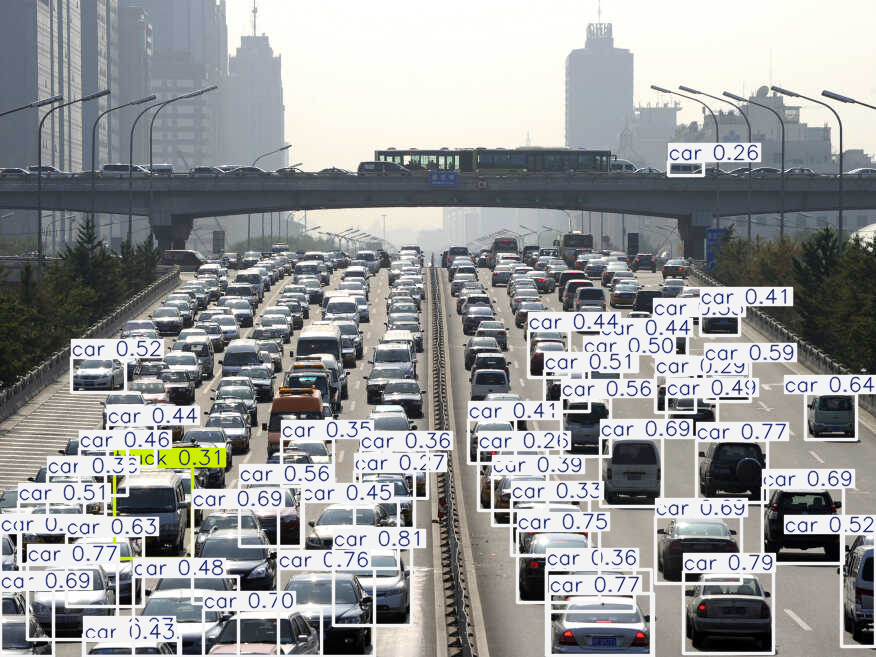

In [39]:
#This cell shows the picture including the detections (Bounding boxes)
from PIL import Image
Image.fromarray(result.plot()[:,:,::-1])

**5. Label your images**

In [40]:
#For image labeling, we strongly encourage you to use Roboflow, which is a free software.
#You will find many instructions online. Try starting here: https://app.roboflow.com/login

#was done there

In [41]:
# splitting data for yaml file
# import os
# import random
# import shutil

# random.seed(42)

# base_dir = "car_images_labeld"

# images_dir = os.path.join(base_dir, "images")
# labels_dir = os.path.join(base_dir, "labels")

# images = [f for f in os.listdir(images_dir) if f.endswith(".png")]

# random.shuffle(images)

# n = len(images)

# train_split = int(0.7 * n)
# val_split = int(0.9 * n)

# train_files = images[:train_split]
# val_files = images[train_split:val_split]
# test_files = images[val_split:]

# for split in ["train", "valid", "test"]:
#     os.makedirs(f"{base_dir}/{split}/images", exist_ok=True)
#     os.makedirs(f"{base_dir}/{split}/labels", exist_ok=True)


# def copy_files(files, split):
#     for img in files:
#         label = os.path.splitext(img)[0] + ".txt"

#         shutil.copy(
#             os.path.join(images_dir, img),
#             os.path.join(base_dir, split, "images", img)
#         )

#         shutil.copy(
#             os.path.join(labels_dir, label),
#             os.path.join(base_dir, split, "labels", label)
#         )


# copy_files(train_files, "train")
# copy_files(val_files, "valid")
# copy_files(test_files, "test")

# print("Dataset erfolgreich aufgeteilt!")

**6. Train your custom model**

In [42]:
#model.train(data="./data.yaml", epochs=1000)

In [43]:
##### here the resultsa gets visualised ######
from pathlib import Path
import pandas as pd

RUN_DIR = Path("runs/detect/train-5")
MODEL_PATH = RUN_DIR / "weights" / "best.pt"

# this is the final model from us
model = YOLO(MODEL_PATH)

metrics = model.val(data="./data.yaml")
results_table = pd.DataFrame({
    "Metric": ["Precision", "Recall", "mAP@50", "mAP@50-95"],
    "Value": [
        metrics.box.mp,
        metrics.box.mr,
        metrics.box.map50,
        metrics.box.map
    ]
})

results_table

Ultralytics 8.4.56  Python-3.10.20 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce MX450, 2048MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1465.9248.1 MB/s, size: 162.5 KB)
val: Scanning C:\Users\reins\OneDrive\Dokumente\Uni\Master 1\Sustainable simulation Game\simulation_game_sustainability\case 3_1\car_images_labeld\valid\labels.cache... 12 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 12/12  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 4.4s/it 4.4s
                   all         12         12      0.995          1      0.995      0.679
Speed: 6.4ms preprocess, 36.4ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to C:\Users\reins\OneDrive\Dokumente\Uni\Master 1\Sustainable simulation Game\simulation_game_sustainability\case 3_1\runs\detect\val-7


,Metric,Value
0,Precision,0.995494
1,Recall,1.000000
2,mAP@50,0.995000
3,mAP@50-95,0.678640


In [44]:
####### confusion matrix #######
from PIL import Image

conf_matrix_path = RUN_DIR / "confusion_matrix.png"

img = Image.open(conf_matrix_path)
img.show()